# Full Yelp Image Clustering Analysis

This notebook analyzes Yelp business/photo data to understand how real public POI images are taken. The goal is not only to group businesses or identify objects, but to mine a taxonomy of capture behavior: camera position, framing, subject focus, occlusion/noise, and what a simulator would need to reproduce web-scale imagery.

**Core workflow:** join Yelp business metadata to photo metadata, assign broad business groups, compute CLIP embeddings, run global and per-group t-SNE, cluster the t-SNE coordinates with HDBSCAN, and write findings from both metadata summaries and representative images.

**Important research stance:** CLIP/t-SNE clusters can easily become semantic clusters such as food, storefronts, or menus. For this project, those semantics are only a starting point. The findings should focus on how the photo was taken and what that means for simulation.

## 0. Setup

This cell verifies the analysis dependencies and can install missing packages. Running CLIP over all 200,100 photos may take a long time on CPU; the notebook caches each major stage under `outputs/` so it can resume.

In [1]:
import importlib.util
import subprocess
import sys
from pathlib import Path

AUTO_INSTALL_MISSING = True

REQUIRED_PACKAGES = {
    "pandas": "pandas",
    "numpy": "numpy",
    "PIL": "pillow",
    "torch": "torch",
    "open_clip": "open_clip_torch",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "tqdm": "tqdm",
    "openTSNE": "openTSNE",
    "hdbscan": "hdbscan",
}

missing = [pip_name for module_name, pip_name in REQUIRED_PACKAGES.items() if importlib.util.find_spec(module_name) is None]
if missing and AUTO_INSTALL_MISSING:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
elif missing:
    raise RuntimeError(f"Missing packages: {missing}. Set AUTO_INSTALL_MISSING=True or install them manually.")
else:
    print("All required packages are available.")

All required packages are available.


In [2]:
import json
import math
import textwrap
from collections import Counter

import hdbscan
import matplotlib.pyplot as plt
import numpy as np
import open_clip
import pandas as pd
import seaborn as sns
import torch
from IPython.display import Markdown, display
from PIL import Image, ImageOps, UnidentifiedImageError
from openTSNE import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

PROJECT_ROOT = Path.cwd()
OUTPUT_DIR = Path(r"C:\\Users\\hmbar\\Downloads\\HCI_CV_1_outputs_gpu")
CACHE_DIR = OUTPUT_DIR / "cache"
FIGURE_DIR = OUTPUT_DIR / "figures"
SHEET_DIR = OUTPUT_DIR / "representative_sheets"
for directory in [OUTPUT_DIR, CACHE_DIR, FIGURE_DIR, SHEET_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

BUSINESS_PATH = Path(r"C:\Users\hmbar\Downloads\Yelp-JSON\Yelp JSON\yelp_dataset\yelp_academic_dataset_business.json")
PHOTOS_JSON_PATH = Path(r"C:\Users\hmbar\Downloads\Yelp-Photos\Yelp Photos\yelp_photos\photos.json")
PHOTO_DIR = Path(r"C:\Users\hmbar\Downloads\Yelp-Photos\Yelp Photos\yelp_photos\photos")

for path in [BUSINESS_PATH, PHOTOS_JSON_PATH, PHOTO_DIR]:
    if not path.exists():
        raise FileNotFoundError(path)

RANDOM_SEED = 42
CLIP_BATCH_SIZE = 64
TSNE_PERPLEXITY = 50
TSNE_N_ITER = 750
PCA_COMPONENTS = 50
REPRESENTATIVES_PER_CLUSTER = 12
MAJOR_GROUPS_FOR_DEEP_DIVE = ["restaurants", "hospitality", "retail", "services"]

print("Notebook working directory:", PROJECT_ROOT.resolve())
print("ALL OUTPUTS WILL BE SAVED HERE:", OUTPUT_DIR.resolve())

C:\Users\hmbar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Notebook working directory: C:\Users\hmbar\Downloads
ALL OUTPUTS WILL BE SAVED HERE: C:\Users\hmbar\Downloads\HCI_CV_1_outputs_gpu


## 1. Load And Join Yelp Metadata

The Yelp photo dataset gives each photo a `business_id`, a caption, and a coarse Yelp label such as `food`, `inside`, `outside`, `drink`, or `menu`. We join this to the business JSON so every photo inherits categories, location, rating, review count, and a broad business group.

In [3]:
def read_json_lines(path: Path, columns=None) -> pd.DataFrame:
    rows = []
    with path.open("r", encoding="utf-8") as handle:
        for line in tqdm(handle, desc=f"Reading {path.name}"):
            record = json.loads(line)
            if columns is not None:
                record = {column: record.get(column) for column in columns}
            rows.append(record)
    return pd.DataFrame(rows)


BUSINESS_CACHE = CACHE_DIR / "businesses.pkl"
PHOTO_CACHE = CACHE_DIR / "photos_joined.pkl"

def split_categories(value):
    if not isinstance(value, str) or not value.strip():
        return []
    return [item.strip() for item in value.split(",") if item.strip()]


GROUP_KEYWORDS = {
    "restaurants": ["Restaurants", "Food", "Bars", "Coffee & Tea", "Bakeries", "Desserts", "Fast Food", "Breakfast & Brunch", "Pizza", "Sandwiches"],
    "hospitality": ["Hotels", "Hotels & Travel", "Resorts", "Bed & Breakfast", "Vacation Rentals", "Event Planning & Services", "Venues & Event Spaces"],
    "retail": ["Shopping", "Fashion", "Department Stores", "Home & Garden", "Furniture Stores", "Electronics", "Grocery", "Bookstores", "Sporting Goods"],
    "services": ["Local Services", "Home Services", "Professional Services", "Real Estate", "Financial Services", "Education", "Pets"],
    "nightlife/entertainment": ["Nightlife", "Arts & Entertainment", "Music Venues", "Cinema", "Performing Arts", "Active Life", "Arcades", "Museums"],
    "health/beauty": ["Health & Medical", "Beauty & Spas", "Doctors", "Dentists", "Massage", "Hair Salons", "Nail Salons", "Fitness & Instruction"],
    "automotive": ["Automotive", "Auto Repair", "Car Dealers", "Oil Change Stations", "Tires", "Gas Stations", "Parking"],
    "outdoor/public": ["Parks", "Public Services & Government", "Landmarks & Historical Buildings", "Beaches", "Hiking", "Public Transportation"],
}

GROUP_PRIORITY = ["restaurants", "hospitality", "retail", "services", "nightlife/entertainment", "health/beauty", "automotive", "outdoor/public"]

def assign_business_group(categories):
    category_set = set(categories)
    for group in GROUP_PRIORITY:
        if category_set.intersection(GROUP_KEYWORDS[group]):
            return group
    return "other"


if PHOTO_CACHE.exists():
    photos = pd.read_pickle(PHOTO_CACHE)
else:
    if BUSINESS_CACHE.exists():
        businesses = pd.read_pickle(BUSINESS_CACHE)
    else:
        businesses = read_json_lines(
            BUSINESS_PATH,
            columns=["business_id", "name", "city", "state", "stars", "review_count", "is_open", "categories"],
        )
        businesses["category_list"] = businesses["categories"].map(split_categories)
        businesses["primary_category"] = businesses["category_list"].map(lambda items: items[0] if items else "")
        businesses["business_group"] = businesses["category_list"].map(assign_business_group)
        businesses.to_pickle(BUSINESS_CACHE)

    photo_meta = read_json_lines(PHOTOS_JSON_PATH)
    photo_meta["image_path"] = photo_meta["photo_id"].map(lambda pid: str(PHOTO_DIR / f"{pid}.jpg"))
    photo_meta["image_exists"] = photo_meta["image_path"].map(lambda value: Path(value).exists())
    photos = photo_meta.merge(businesses, on="business_id", how="left", validate="many_to_one")
    photos["business_group"] = photos["business_group"].fillna("other")
    photos["category_list"] = photos["category_list"].map(lambda value: value if isinstance(value, list) else [])
    photos.to_pickle(PHOTO_CACHE)

photos.head()

Reading yelp_academic_dataset_business.json: 150346it [00:01, 75585.36it/s]
Reading photos.json: 200100it [00:00, 247652.29it/s]


,photo_id,business_id,caption,label,image_path,image_exists,name,city,state,stars,review_count,is_open,categories,category_list,primary_category,business_group
0,zsvj7vloL4L5jhYyPIuVwg,Nk-SJhPlDBkAZvfsADtccA,Nice rock artwork everywhere and craploads of taps.,inside,C:\Users\hmbar\Downloads\Yelp-Photos\Yelp Photos\yelp_photos\photos\zsvj7vloL4L5jhYyPIuVwg.jpg,True,HopCat - Broad Ripple,Indianapolis,IN,3.5,657,1,"Restaurants, Pubs, Nightlife, American (Traditional), Bars, Beer Bar, Burgers","[Restaurants, Pubs, Nightlife, American (Traditional), Bars, Beer Bar, Burgers]",Restaurants,restaurants
1,HCUdRJHHm_e0OCTlZetGLg,yVZtL5MmrpiivyCIrVkGgA,,outside,C:\Users\hmbar\Downloads\Yelp-Photos\Yelp Photos\yelp_photos\photos\HCUdRJHHm_e0OCTlZetGLg.jpg,True,Hogtown Smokehouse,St. Louis,MO,4.5,67,1,"Barbeque, Sandwiches, American (Traditional), Restaurants","[Barbeque, Sandwiches, American (Traditional), Restaurants]",Barbeque,restaurants
2,vkr8T0scuJmGVvN2HJelEA,_ab50qdWOk0DdB6XOrBitw,oyster shooter,drink,C:\Users\hmbar\Downloads\Yelp-Photos\Yelp Photos\yelp_photos\photos\vkr8T0scuJmGVvN2HJelEA.jpg,True,Acme Oyster House,New Orleans,LA,4.0,7568,1,"Live/Raw Food, Seafood, Restaurants, Cajun/Creole","[Live/Raw Food, Seafood, Restaurants, Cajun/Creole]",Live/Raw Food,restaurants
3,pve7D6NUrafHW3EAORubyw,SZU9c8V2GuREDN5KgyHFJw,Shrimp scampi,food,C:\Users\hmbar\Downloads\Yelp-Photos\Yelp Photos\yelp_photos\photos\pve7D6NUrafHW3EAORubyw.jpg,True,Santa Barbara Shellfish Company,Santa Barbara,CA,4.0,2404,1,"Live/Raw Food, Restaurants, Seafood, Beer Bar, Beer, Wine & Spirits, Bars, Food, Nightlife","[Live/Raw Food, Restaurants, Seafood, Beer Bar, Beer, Wine & Spirits, Bars, Food, Nightlife]",Live/Raw Food,restaurants
4,H52Er-uBg6rNrHcReWTD2w,Gzur0f0XMkrVxIwYJvOt2g,,food,C:\Users\hmbar\Downloads\Yelp-Photos\Yelp Photos\yelp_photos\photos\H52Er-uBg6rNrHcReWTD2w.jpg,True,The Poké Company,Tampa,FL,4.5,54,1,"Restaurants, Vegan, Food, Ice Cream & Frozen Yogurt, Gluten-Free, Coffee & Tea, Event Planning & Services, Poke, Cat...","[Restaurants, Vegan, Food, Ice Cream & Frozen Yogurt, Gluten-Free, Coffee & Tea, Event Planning & Services, Poke, Ca...",Restaurants,restaurants


## 2. Metadata Findings

This section gives the first useful meeting findings before any image model runs: how many photos are available, how they distribute across Yelp labels, and how much each broad business group contributes.

In [4]:
def top_counts(series, n=10):
    return series.value_counts(dropna=False).head(n)

def category_counter(frame):
    counter = Counter()
    for categories in frame["category_list"]:
        counter.update(categories)
    return counter

n_photos = len(photos)
n_photo_businesses = photos["business_id"].nunique()
n_missing_images = int((~photos["image_exists"]).sum())
n_missing_business = int(photos["name"].isna().sum())
label_counts = top_counts(photos["label"], 10)
group_counts = top_counts(photos["business_group"], 20)
unique_categories = len(category_counter(photos))

display(Markdown(f"""
### Metadata Findings

- Loaded **{n_photos:,} photos** across **{n_photo_businesses:,} businesses**.
- Found **{unique_categories:,} unique Yelp categories** represented in the joined photo set.
- Missing image files: **{n_missing_images:,}**. Missing joined business rows: **{n_missing_business:,}**.
- Yelp photo labels are useful but coarse. They should be treated as weak metadata, not final camera/context labels.
- The next question is whether CLIP/t-SNE clusters reveal capture patterns inside each broad business group, especially when the same semantic class appears in different camera positions.
"""))

display(pd.DataFrame({"photo_count": label_counts, "share": (label_counts / n_photos).round(4)}))
display(pd.DataFrame({"photo_count": group_counts, "share": (group_counts / n_photos).round(4)}))


### Metadata Findings

- Loaded **200,100 photos** across **36,680 businesses**.
- Found **666 unique Yelp categories** represented in the joined photo set.
- Missing image files: **0**. Missing joined business rows: **0**.
- Yelp photo labels are useful but coarse. They should be treated as weak metadata, not final camera/context labels.
- The next question is whether CLIP/t-SNE clusters reveal capture patterns inside each broad business group, especially when the same semantic class appears in different camera positions.


,photo_count,share
label,,
food,108152,0.5405
inside,56031,0.2800
outside,18569,0.0928
drink,15670,0.0783
menu,1678,0.0084


,photo_count,share
business_group,,
restaurants,198510,0.9921
nightlife/entertainment,849,0.0042
hospitality,598,0.0030
services,109,0.0005
retail,34,0.0002


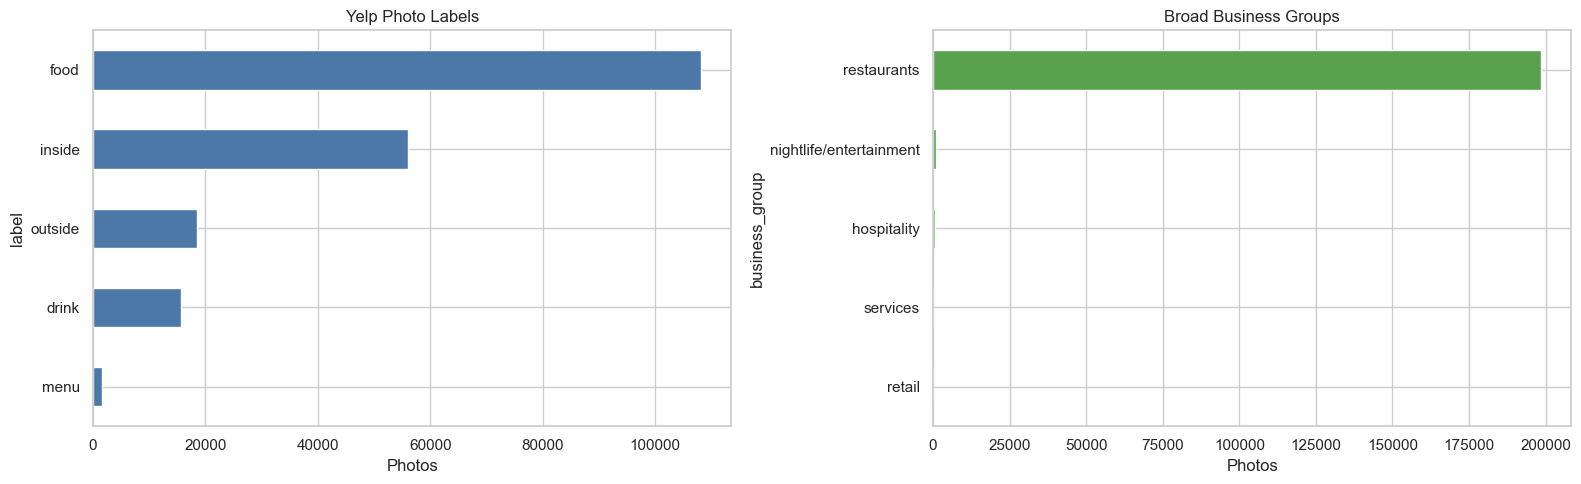

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
label_counts.sort_values().plot(kind="barh", ax=axes[0], color="#4C78A8")
axes[0].set_title("Yelp Photo Labels")
axes[0].set_xlabel("Photos")
group_counts.sort_values().plot(kind="barh", ax=axes[1], color="#59A14F")
axes[1].set_title("Broad Business Groups")
axes[1].set_xlabel("Photos")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "metadata_distributions.png", dpi=180)
plt.show()

## 3. Compute CLIP Image Embeddings

CLIP gives a semantic embedding for each image. The analysis uses those embeddings as a starting point, but the interpretation cells below deliberately reframe clusters around photo capture behavior: close-up versus wide shot, interior versus exterior, table-level versus entrance/threshold, and so on.

In [6]:
EMBEDDING_PATH = CACHE_DIR / "clip_image_embeddings_float32.npy"
EMBEDDING_IDS_PATH = CACHE_DIR / "clip_photo_ids.npy"

def load_clip_model():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model, _, preprocess = open_clip.create_model_and_transforms("ViT-B-32", pretrained="laion2b_s34b_b79k")
    tokenizer = open_clip.get_tokenizer("ViT-B-32")
    model = model.to(device).eval()
    print(f"Using device: {device}")
    return model, preprocess, tokenizer, device

def safe_open_image(path):
    try:
        return Image.open(path).convert("RGB")
    except (FileNotFoundError, UnidentifiedImageError, OSError):
        return Image.new("RGB", (224, 224), color=(0, 0, 0))

def compute_clip_embeddings(frame: pd.DataFrame, batch_size=CLIP_BATCH_SIZE):
    if EMBEDDING_PATH.exists() and EMBEDDING_IDS_PATH.exists():
        embeddings = np.load(EMBEDDING_PATH, mmap_mode="r")
        photo_ids = np.load(EMBEDDING_IDS_PATH, allow_pickle=True)
        if len(photo_ids) == len(frame) and np.array_equal(photo_ids.astype(str), frame["photo_id"].astype(str).to_numpy()):
            print("Loaded cached CLIP embeddings:", embeddings.shape)
            return embeddings
        print("Cached embeddings do not match current photo order; recomputing.")

    model, preprocess, _, device = load_clip_model()
    paths = frame["image_path"].tolist()
    photo_ids = frame["photo_id"].astype(str).to_numpy()
    embedding_memmap = None

    with torch.no_grad():
        for start in tqdm(range(0, len(paths), batch_size), desc="CLIP image batches"):
            batch_paths = paths[start:start + batch_size]
            images = torch.stack([preprocess(safe_open_image(path)) for path in batch_paths]).to(device)
            features = model.encode_image(images)
            features = features / features.norm(dim=-1, keepdim=True)
            batch_embeddings = features.detach().cpu().numpy().astype("float32")

            if embedding_memmap is None:
                embedding_memmap = np.lib.format.open_memmap(
                    EMBEDDING_PATH,
                    mode="w+",
                    dtype="float32",
                    shape=(len(paths), batch_embeddings.shape[1]),
                )

            embedding_memmap[start:start + len(batch_embeddings)] = batch_embeddings
            embedding_memmap.flush()

    np.save(EMBEDDING_IDS_PATH, photo_ids)
    return np.load(EMBEDDING_PATH, mmap_mode="r")


embeddings = compute_clip_embeddings(photos)
embeddings.shape

Using device: cuda


CLIP image batches: 100%|██████████████████████████████████████████████████████████| 3127/3127 [37:50<00:00,  1.38it/s]


(200100, 512)

## 4. CLIP Language Prompts For Cluster Interpretation

These prompts are not labels by themselves. They are interpretive probes that help describe each cluster in terms of semantic content and image-capture behavior.

In [7]:
CLIP_PROMPTS = [
    "a close-up photo of food or a small object",
    "a wide interior scene of a business",
    "an exterior storefront photo",
    "a photo of a menu or sign",
    "a photo centered on people",
    "a table-level photo from a seated position",
    "an aisle or pathway view through a business",
    "a room corner or edge-of-room view",
    "a blurry or low-quality photo",
    "an occluded scene with objects or people blocking the view",
]

TEXT_EMBEDDING_PATH = CACHE_DIR / "clip_text_prompt_embeddings.npy"

def compute_text_embeddings(prompts):
    if TEXT_EMBEDDING_PATH.exists():
        return np.load(TEXT_EMBEDDING_PATH)
    model, _, tokenizer, device = load_clip_model()
    with torch.no_grad():
        tokens = tokenizer(prompts).to(device)
        text_features = model.encode_text(tokens)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
    result = text_features.detach().cpu().numpy().astype("float32")
    np.save(TEXT_EMBEDDING_PATH, result)
    return result

text_embeddings = compute_text_embeddings(CLIP_PROMPTS)
prompt_similarity = np.asarray(embeddings @ text_embeddings.T, dtype="float32")
prompt_similarity.shape

Using device: cuda


(200100, 10)

## 5. Global PCA, t-SNE, And HDBSCAN

The global pass asks: across all Yelp photos, what broad capture modes emerge? We reduce CLIP vectors with PCA, run t-SNE for neighborhood structure, then use HDBSCAN because the number and shape of clusters are unknown. HDBSCAN's `-1` label is treated as meaningful noise/outlier imagery rather than a failure.

In [8]:
def pca_then_tsne(name, matrix, perplexity=TSNE_PERPLEXITY, n_iter=TSNE_N_ITER):
    tsne_path = CACHE_DIR / f"{name}_tsne2d.npy"
    pca_path = CACHE_DIR / f"{name}_pca50.npy"
    if tsne_path.exists():
        return np.load(tsne_path)
    if pca_path.exists():
        reduced = np.load(pca_path, mmap_mode="r")
    else:
        n_components = min(PCA_COMPONENTS, matrix.shape[1], matrix.shape[0] - 1)
        reduced = PCA(n_components=n_components, random_state=RANDOM_SEED).fit_transform(np.asarray(matrix))
        np.save(pca_path, reduced.astype("float32"))
    tsne = TSNE(
        n_components=2,
        perplexity=min(perplexity, max(5, (len(reduced) - 1) // 3)),
        n_iter=n_iter,
        metric="cosine",
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbose=True,
    )
    coords = tsne.fit(np.asarray(reduced)).astype("float32")
    np.save(tsne_path, coords)
    return coords

def hdbscan_cluster(name, coords, min_cluster_size=None):
    label_path = CACHE_DIR / f"{name}_hdbscan_labels.npy"
    prob_path = CACHE_DIR / f"{name}_hdbscan_probabilities.npy"
    if label_path.exists() and prob_path.exists():
        return np.load(label_path), np.load(prob_path)
    if min_cluster_size is None:
        min_cluster_size = max(50, int(round(len(coords) * 0.0025)))
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=max(10, min_cluster_size // 5),
        cluster_selection_method="eom",
        prediction_data=False,
    )
    labels = clusterer.fit_predict(coords)
    probabilities = clusterer.probabilities_.astype("float32")
    np.save(label_path, labels)
    np.save(prob_path, probabilities)
    return labels, probabilities

global_tsne = pca_then_tsne("global", embeddings)
global_labels, global_probabilities = hdbscan_cluster("global", global_tsne)

photos["global_tsne_x"] = global_tsne[:, 0]
photos["global_tsne_y"] = global_tsne[:, 1]
photos["global_cluster"] = global_labels
photos["global_cluster_probability"] = global_probabilities

cluster_count = len(set(global_labels) - {-1})
noise_ratio = float((global_labels == -1).mean())
display(Markdown(f"Global HDBSCAN found **{cluster_count} clusters** with **{noise_ratio:.1%} noise/outlier photos**."))

--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, metric='cosine', n_iter=750, n_jobs=-1,
     perplexity=50, random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 150 nearest neighbors using Annoy approximate search using cosine distance...
   --> Time elapsed: 71.90 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 64.84 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.06 seconds
===> Running optimization with exaggeration=12.00, lr=16675.00 for 250 iterations...
Iteration   50, KL divergence 6.8817, 50 iterations in 9.7964 sec
Iteration  100, KL divergence 6.8967, 50 iterations in 9.4224 sec
Iteration  150, KL divergence 6.8974, 50 iterations in 8.7795 sec
Iteration  200, KL divergence 6.9003, 50 iterations in 9.8571 sec
Iteration  250, KL divergence 6.9010, 50 iterations in 9.4399 sec
   --> Time elapsed: 47.30 s

Global HDBSCAN found **14 clusters** with **15.5% noise/outlier photos**.

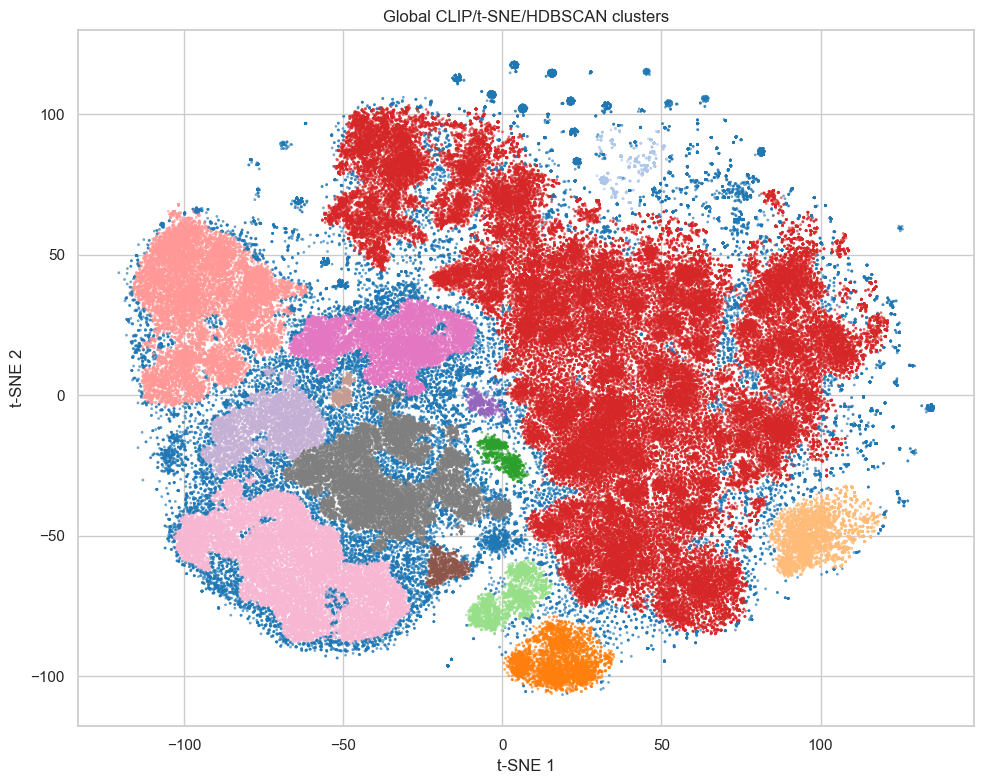

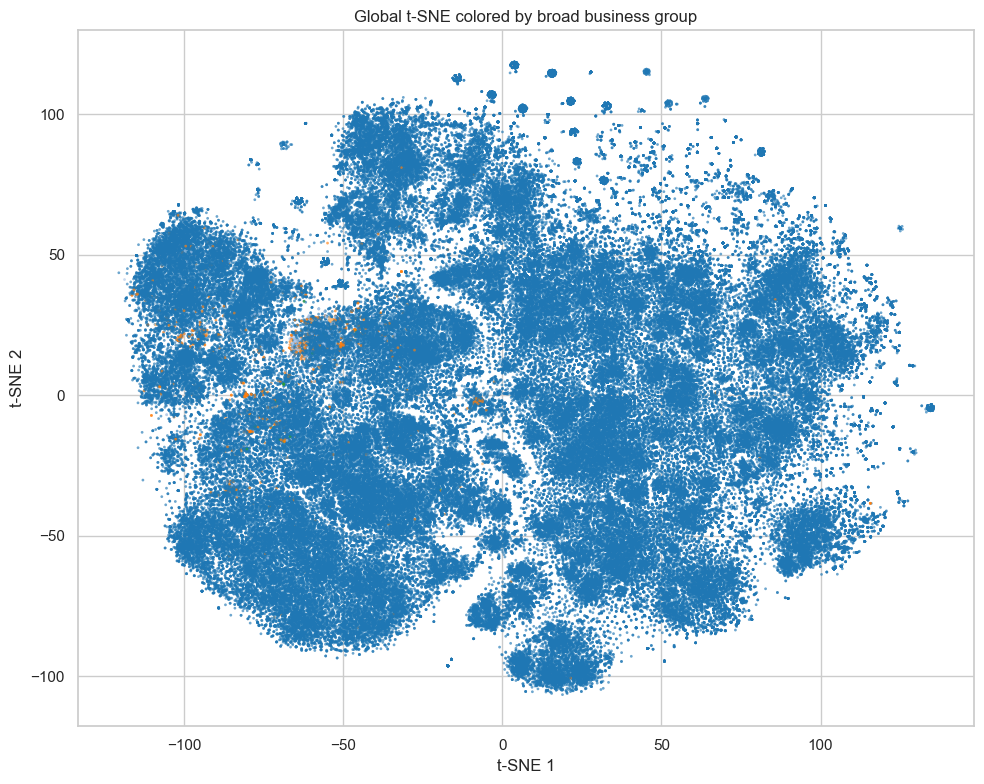

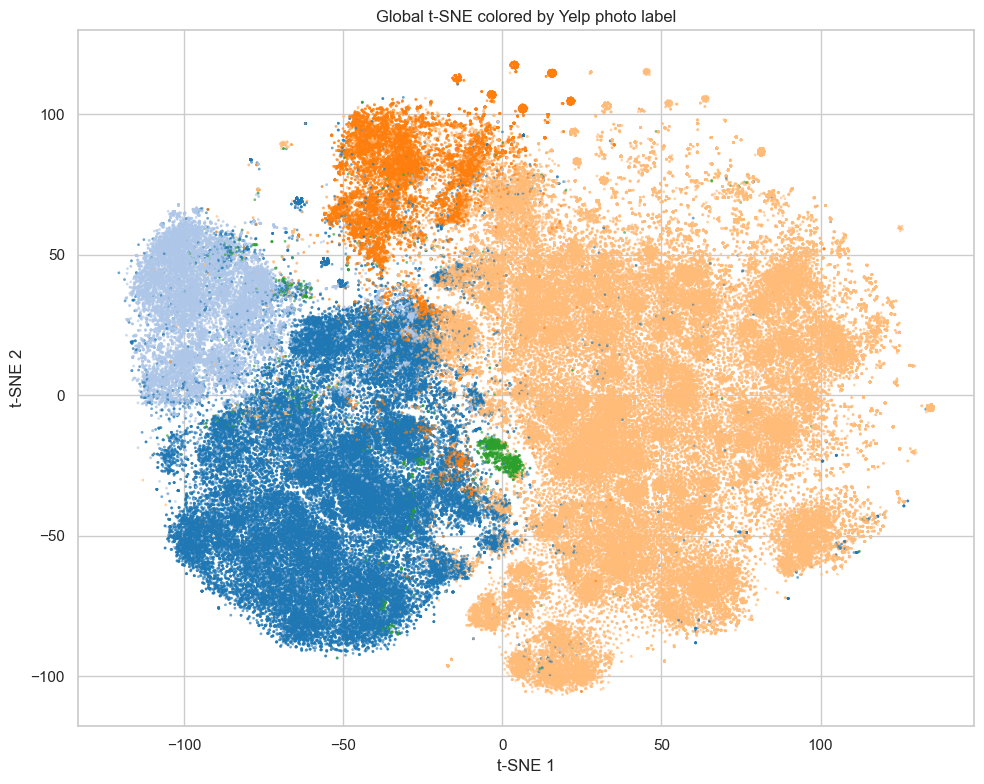

In [9]:
def plot_tsne(frame, x_col, y_col, hue_col, title, path):
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.scatterplot(
        data=frame,
        x=x_col,
        y=y_col,
        hue=hue_col,
        s=4,
        linewidth=0,
        alpha=0.65,
        palette="tab20",
        ax=ax,
        legend=False,
    )
    ax.set_title(title)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    plt.tight_layout()
    fig.savefig(path, dpi=180)
    plt.show()

plot_tsne(photos, "global_tsne_x", "global_tsne_y", "global_cluster", "Global CLIP/t-SNE/HDBSCAN clusters", FIGURE_DIR / "global_tsne_hdbscan.png")
plot_tsne(photos, "global_tsne_x", "global_tsne_y", "business_group", "Global t-SNE colored by broad business group", FIGURE_DIR / "global_tsne_business_groups.png")
plot_tsne(photos, "global_tsne_x", "global_tsne_y", "label", "Global t-SNE colored by Yelp photo label", FIGURE_DIR / "global_tsne_yelp_labels.png")

## 6. Cluster Summaries And Representative Images

For each cluster, this section records the dominant Yelp labels, business groups, categories, CLIP prompt matches, and representative photos. These are the raw materials for the findings notes.

In [10]:
def summarize_clusters(frame, cluster_col, probability_col, prompt_scores, prefix, top_n=8):
    work = frame.reset_index(drop=True)
    rows = []
    for cluster_id in sorted([value for value in work[cluster_col].unique() if value != -1]):
        subset = work[work[cluster_col] == cluster_id]
        indices = subset.index.to_numpy()
        prompt_means = prompt_scores[indices].mean(axis=0)
        top_prompt_ids = np.argsort(prompt_means)[::-1][:3]
        category_counts = category_counter(subset).most_common(5)
        rows.append({
            "cluster": int(cluster_id),
            "n_photos": len(subset),
            "mean_membership_probability": float(subset[probability_col].mean()),
            "top_yelp_labels": ", ".join([f"{k} ({v})" for k, v in subset["label"].value_counts().head(4).items()]),
            "top_business_groups": ", ".join([f"{k} ({v})" for k, v in subset["business_group"].value_counts().head(4).items()]),
            "top_categories": ", ".join([f"{k} ({v})" for k, v in category_counts]),
            "top_clip_prompts": " | ".join([CLIP_PROMPTS[i] for i in top_prompt_ids]),
        })
    summary = pd.DataFrame(rows)
    if summary.empty:
        summary = pd.DataFrame(columns=[
            "cluster",
            "n_photos",
            "mean_membership_probability",
            "top_yelp_labels",
            "top_business_groups",
            "top_categories",
            "top_clip_prompts",
        ])
    else:
        summary = summary.sort_values(["n_photos"], ascending=False)
    summary.to_csv(OUTPUT_DIR / f"{prefix}_cluster_summary.csv", index=False)
    return summary

def make_representative_sheet(frame, cluster_col, probability_col, prefix, max_clusters=24, per_cluster=REPRESENTATIVES_PER_CLUSTER):
    cluster_ids = [value for value in frame[cluster_col].value_counts().index.tolist() if value != -1][:max_clusters]
    rows = []
    for cluster_id in cluster_ids:
        subset = frame[frame[cluster_col] == cluster_id].sort_values(probability_col, ascending=False).head(per_cluster)
        rows.append((cluster_id, subset))
    if not rows:
        return None

    thumb_size = 128
    label_height = 32
    width = per_cluster * thumb_size
    height = len(rows) * (thumb_size + label_height)
    canvas = Image.new("RGB", (width, height), "white")

    for row_idx, (cluster_id, subset) in enumerate(rows):
        y0 = row_idx * (thumb_size + label_height)
        for col_idx, (_, item) in enumerate(subset.iterrows()):
            image = safe_open_image(item["image_path"])
            image = ImageOps.fit(image, (thumb_size, thumb_size), method=Image.Resampling.LANCZOS)
            canvas.paste(image, (col_idx * thumb_size, y0 + label_height))
    path = SHEET_DIR / f"{prefix}_representatives.jpg"
    canvas.save(path, quality=92)
    return path

global_summary = summarize_clusters(photos, "global_cluster", "global_cluster_probability", prompt_similarity, "global")
global_sheet = make_representative_sheet(photos, "global_cluster", "global_cluster_probability", "global")
display(global_summary.head(20))
display(Markdown(f"Representative image sheet: `{global_sheet}`"))

,cluster,n_photos,mean_membership_probability,top_yelp_labels,top_business_groups,top_categories,top_clip_prompts
5,5,90498,0.988688,"food (77791), drink (11571), inside (901), outside (167)","restaurants (90463), hospitality (19), nightlife/entertainment (15), retail (1)","Restaurants (81262), Food (35260), Nightlife (25920), Bars (25304), American (New) (18902)",a close-up photo of food or a small object | a photo of a menu or sign | a blurry or low-quality photo
12,12,17009,0.961379,"inside (16711), outside (203), menu (77), food (9)","restaurants (16931), nightlife/entertainment (47), hospitality (28), services (3)","Restaurants (14766), Food (6737), Nightlife (6350), Bars (6064), American (New) (3729)",a wide interior scene of a business | a table-level photo from a seated position | a photo of a menu or sign
6,6,15664,0.985901,"outside (14780), inside (753), menu (79), food (36)","restaurants (15380), nightlife/entertainment (170), hospitality (93), services (19)","Restaurants (12795), Food (6472), Nightlife (5858), Bars (5329), American (Traditional) (3584)",an exterior storefront photo | a photo of a menu or sign | a blurry or low-quality photo
13,13,14963,0.983486,"inside (13638), drink (624), food (382), outside (198)","restaurants (14935), nightlife/entertainment (19), hospitality (6), retail (2)","Restaurants (11256), Food (7871), Nightlife (5440), Bars (5258), American (New) (2727)",a wide interior scene of a business | a photo of a menu or sign | a table-level photo from a seated position
11,11,9392,0.983110,"inside (6699), food (1498), outside (712), drink (478)","restaurants (8808), nightlife/entertainment (285), hospitality (228), services (59)","Restaurants (6971), Nightlife (5442), Bars (4489), Food (2717), Arts & Entertainment (2346)",a table-level photo from a seated position | a blurry or low-quality photo | a photo centered on people
8,8,5257,0.976274,"inside (4784), outside (295), food (102), menu (59)","restaurants (5033), nightlife/entertainment (98), hospitality (92), services (19)","Restaurants (4028), Nightlife (2307), Food (2078), Bars (1992), American (New) (981)",a blurry or low-quality photo | a room corner or edge-of-room view | a photo of a menu or sign
2,2,4779,0.773481,"food (4714), inside (57), outside (3), menu (3)","restaurants (4776), nightlife/entertainment (3)","Restaurants (4731), Pizza (4037), Italian (1879), Food (1157), Sandwiches (1026)",a close-up photo of food or a small object | a photo of a menu or sign | a table-level photo from a seated position
1,1,4349,0.971189,"food (4297), inside (38), menu (6), drink (4)","restaurants (4347), hospitality (1), nightlife/entertainment (1)","Restaurants (4295), Sushi Bars (3480), Japanese (2905), Asian Fusion (1179), Food (775)",a close-up photo of food or a small object | a photo of a menu or sign | a table-level photo from a seated position
4,4,2836,0.980029,"food (2816), inside (12), outside (4), drink (4)","restaurants (2829), hospitality (6), nightlife/entertainment (1)","Restaurants (2763), Seafood (1909), Cajun/Creole (994), Nightlife (993), Bars (973)",a close-up photo of food or a small object | a photo of a menu or sign | a blurry or low-quality photo
0,0,1152,0.950682,"food (1137), drink (13), menu (1), inside (1)",restaurants (1152),"Restaurants (962), Breakfast & Brunch (715), American (Traditional) (595), Food (499), Diners (341)",a close-up photo of food or a small object | a photo of a menu or sign | a table-level photo from a seated position


Representative image sheet: `C:\Users\hmbar\Downloads\HCI_CV_1_outputs_gpu\representative_sheets\global_representatives.jpg`

## 7. Global CLIP/t-SNE/HDBSCAN Findings

Use the table and representative image sheet above to write short findings. Keep these notes focused on camera/context behavior, not just object classes.

In [11]:
def auto_finding_notes(summary, title):
    if summary.empty:
        return f"### {title}\n\nNo stable clusters were found; HDBSCAN treated all points as noise/outliers. That itself suggests this subset may be too heterogeneous or needs different t-SNE/HDBSCAN parameters."
    largest = summary.head(5)
    bullets = []
    for _, row in largest.iterrows():
        bullets.append(
            f"- Cluster {row['cluster']} contains {row['n_photos']:,} photos. "
            f"Top Yelp labels: {row['top_yelp_labels']}. "
            f"Top CLIP probes: {row['top_clip_prompts']}. "
            "Interpret this by inspecting the representative sheet and deciding whether the cluster is about subject matter, camera position, framing, or image quality."
        )
    return f"### {title}\n\n" + "\n".join(bullets)

global_findings_md = auto_finding_notes(global_summary, "Global Findings Draft")
display(Markdown(global_findings_md))

### Global Findings Draft

- Cluster 5 contains 90,498 photos. Top Yelp labels: food (77791), drink (11571), inside (901), outside (167). Top CLIP probes: a close-up photo of food or a small object | a photo of a menu or sign | a blurry or low-quality photo. Interpret this by inspecting the representative sheet and deciding whether the cluster is about subject matter, camera position, framing, or image quality.
- Cluster 12 contains 17,009 photos. Top Yelp labels: inside (16711), outside (203), menu (77), food (9). Top CLIP probes: a wide interior scene of a business | a table-level photo from a seated position | a photo of a menu or sign. Interpret this by inspecting the representative sheet and deciding whether the cluster is about subject matter, camera position, framing, or image quality.
- Cluster 6 contains 15,664 photos. Top Yelp labels: outside (14780), inside (753), menu (79), food (36). Top CLIP probes: an exterior storefront photo | a photo of a menu or sign | a blurry or low-quality photo. Interpret this by inspecting the representative sheet and deciding whether the cluster is about subject matter, camera position, framing, or image quality.
- Cluster 13 contains 14,963 photos. Top Yelp labels: inside (13638), drink (624), food (382), outside (198). Top CLIP probes: a wide interior scene of a business | a photo of a menu or sign | a table-level photo from a seated position. Interpret this by inspecting the representative sheet and deciding whether the cluster is about subject matter, camera position, framing, or image quality.
- Cluster 11 contains 9,392 photos. Top Yelp labels: inside (6699), food (1498), outside (712), drink (478). Top CLIP probes: a table-level photo from a seated position | a blurry or low-quality photo | a photo centered on people. Interpret this by inspecting the representative sheet and deciding whether the cluster is about subject matter, camera position, framing, or image quality.

In [15]:
def summarize_clusters(frame, cluster_col, probability_col, prompt_scores, prefix, top_n=8):
    work = frame.reset_index(drop=True)
    rows = []

    for cluster_id in sorted([value for value in work[cluster_col].unique() if value != -1]):
        subset = work[work[cluster_col] == cluster_id]
        indices = subset.index.to_numpy()

        if len(subset) == 0:
            continue

        prompt_means = prompt_scores[indices].mean(axis=0)
        top_prompt_ids = np.argsort(prompt_means)[::-1][:3]
        category_counts = category_counter(subset).most_common(5)

        rows.append({
            "cluster": int(cluster_id),
            "n_photos": len(subset),
            "mean_membership_probability": float(subset[probability_col].mean()),
            "top_yelp_labels": ", ".join([f"{k} ({v})" for k, v in subset["label"].value_counts().head(4).items()]),
            "top_business_groups": ", ".join([f"{k} ({v})" for k, v in subset["business_group"].value_counts().head(4).items()]),
            "top_categories": ", ".join([f"{k} ({v})" for k, v in category_counts]),
            "top_clip_prompts": " | ".join([CLIP_PROMPTS[i] for i in top_prompt_ids]),
        })

    if rows:
        summary = pd.DataFrame(rows).sort_values(["n_photos"], ascending=False)
    else:
        summary = pd.DataFrame(columns=[
            "cluster",
            "n_photos",
            "mean_membership_probability",
            "top_yelp_labels",
            "top_business_groups",
            "top_categories",
            "top_clip_prompts",
        ])

    summary.to_csv(OUTPUT_DIR / f"{prefix}_cluster_summary.csv", index=False)
    return summary

print("Patched summarize_clusters loaded. Now rerun section 8.")

Patched summarize_clusters loaded. Now rerun section 8.


## 8. Per-Group t-SNE And HDBSCAN

This is the deeper analysis requested in the project notes: after the global pass, rerun t-SNE and unsupervised clustering within specific business groups. This helps reveal striations inside restaurants, hospitality, retail, and services that would be flattened in the global visualization.

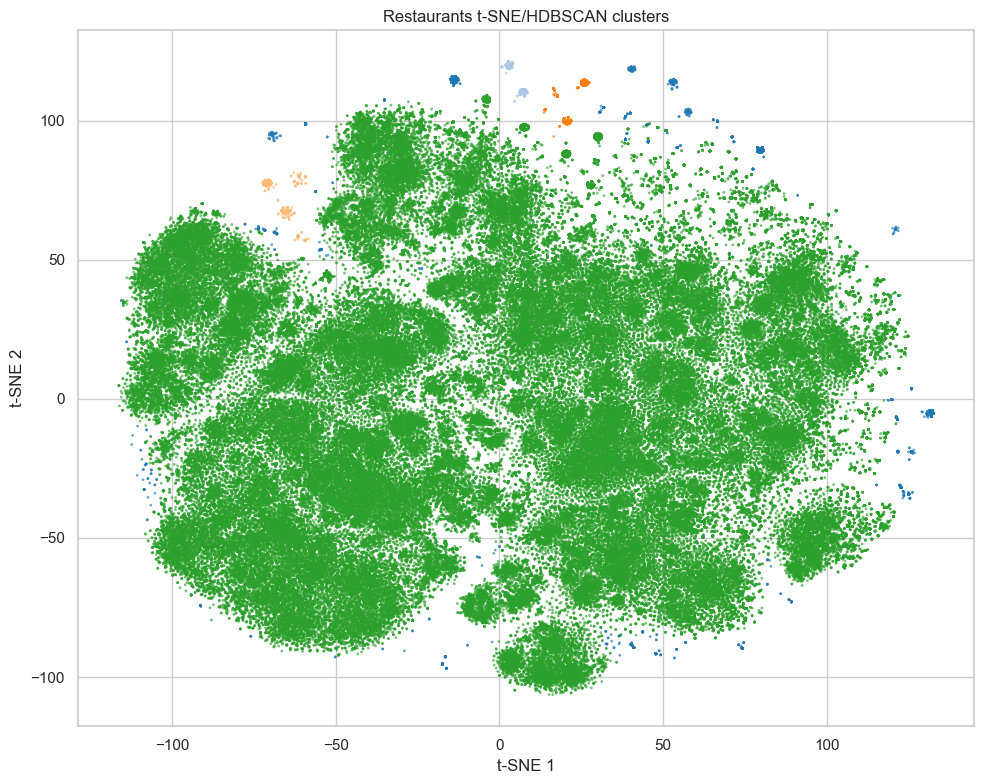

### Restaurants
Representative image sheet: `C:\Users\hmbar\Downloads\HCI_CV_1_outputs_gpu\representative_sheets\group_restaurants_representatives.jpg`

,cluster,n_photos,mean_membership_probability,top_yelp_labels,top_business_groups,top_categories,top_clip_prompts
3,3,193151,0.996334,"food (104978), inside (54091), outside (18011), drink (14409)",restaurants (193151),"Restaurants (167353), Food (76280), Nightlife (59338), Bars (57280), American (Traditional) (38065)",a close-up photo of food or a small object | a photo of a menu or sign | a table-level photo from a seated position
2,2,955,0.922631,"inside (748), food (163), outside (31), drink (13)",restaurants (955),"Food (910), Coffee & Tea (586), Shopping (309), Drugstores (303), Convenience Stores (300)",a table-level photo from a seated position | a wide interior scene of a business | a blurry or low-quality photo
1,1,657,0.999884,"drink (352), food (305)",restaurants (657),"Food (565), Coffee & Tea (502), Donuts (497), Restaurants (321), Burgers (154)",a close-up photo of food or a small object | a blurry or low-quality photo | a photo of a menu or sign
0,0,501,1.000000,"drink (499), food (2)",restaurants (501),"Food (498), Coffee & Tea (496), Donuts (248), Restaurants (126), Bakeries (25)",a close-up photo of food or a small object | a blurry or low-quality photo | a table-level photo from a seated position


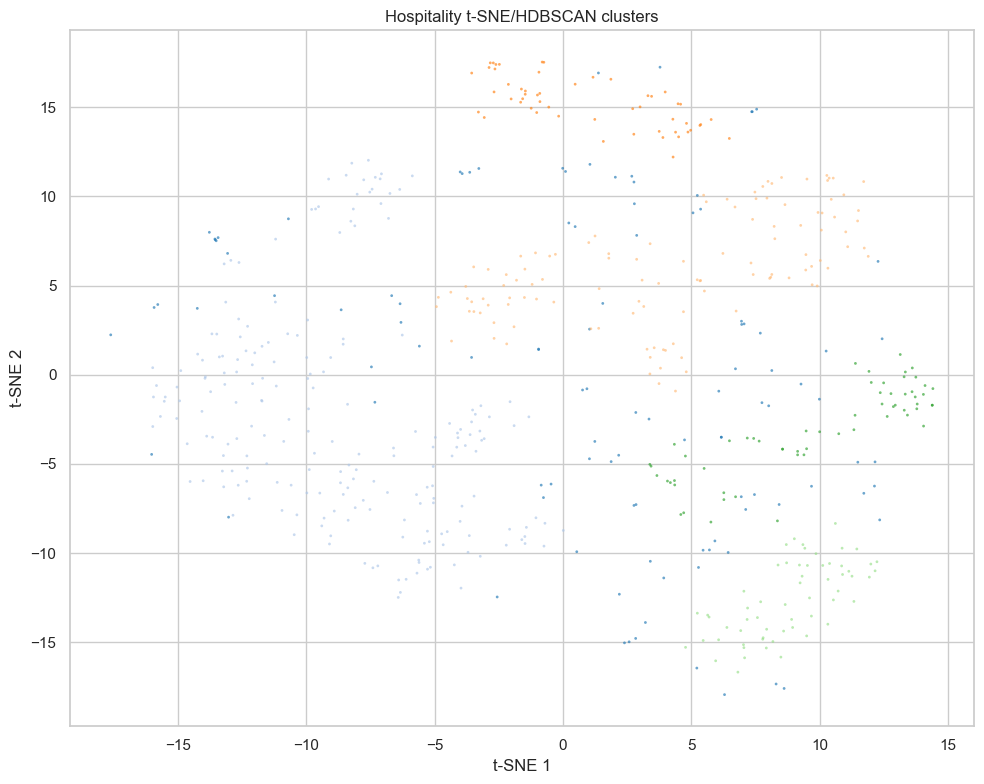

### Hospitality
Representative image sheet: `C:\Users\hmbar\Downloads\HCI_CV_1_outputs_gpu\representative_sheets\group_hospitality_representatives.jpg`

,cluster,n_photos,mean_membership_probability,top_yelp_labels,top_business_groups,top_categories,top_clip_prompts
0,0,205,0.916394,"inside (162), outside (42), drink (1)",hospitality (205),"Nightlife (202), Arts & Entertainment (190), Music Venues (183), Event Planning & Services (135), Performing Arts (118)",a blurry or low-quality photo | a table-level photo from a seated position | a photo centered on people
2,2,114,0.988568,"inside (58), outside (52), drink (2), menu (1)",hospitality (114),"Nightlife (111), Arts & Entertainment (105), Event Planning & Services (105), Music Venues (103), Venues & Event Spa...",a blurry or low-quality photo | a table-level photo from a seated position | a photo of a menu or sign
3,3,60,0.997752,inside (60),hospitality (60),"Nightlife (60), Arts & Entertainment (59), Music Venues (57), Performing Arts (36), Event Planning & Services (33)",a wide interior scene of a business | a room corner or edge-of-room view | a table-level photo from a seated position
4,4,60,0.985961,"inside (50), outside (9), food (1)",hospitality (60),"Event Planning & Services (60), Nightlife (60), Arts & Entertainment (53), Music Venues (40), Venues & Event Spaces ...",a table-level photo from a seated position | a blurry or low-quality photo | a photo centered on people
1,1,53,0.997343,"food (25), outside (23), inside (3), drink (2)",hospitality (53),"Event Planning & Services (52), Venues & Event Spaces (49), Active Life (37), Skating Rinks (35), Arts & Entertainme...",a close-up photo of food or a small object | a blurry or low-quality photo | a table-level photo from a seated position


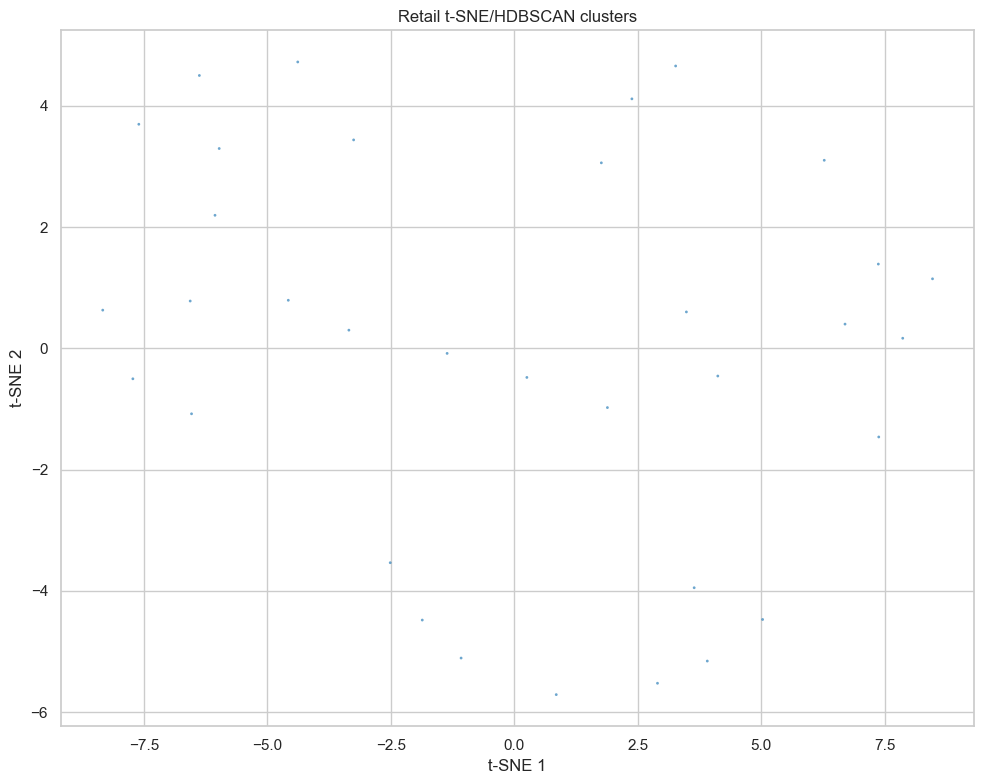

### Retail
Representative image sheet: `None`

,cluster,n_photos,mean_membership_probability,top_yelp_labels,top_business_groups,top_categories,top_clip_prompts


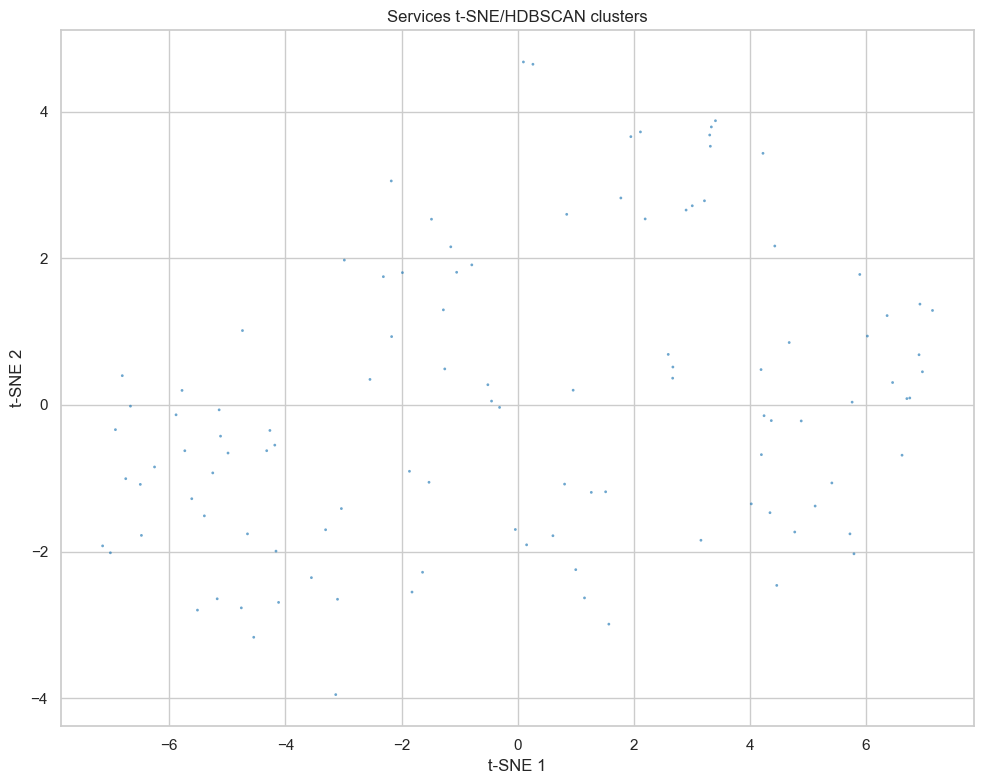

### Services
Representative image sheet: `None`

,cluster,n_photos,mean_membership_probability,top_yelp_labels,top_business_groups,top_categories,top_clip_prompts


In [16]:
group_summaries = {}

for group in MAJOR_GROUPS_FOR_DEEP_DIVE:
    group_mask = photos["business_group"].eq(group).to_numpy()
    group_frame = photos.loc[group_mask].copy()
    if len(group_frame) < 25:
        print(f"Skipping {group}: only {len(group_frame)} photos")
        continue

    safe_group_name = group.replace("/", "_")
    group_embeddings = np.asarray(embeddings[group_mask])
    coords = pca_then_tsne(f"group_{safe_group_name}", group_embeddings)
    labels, probabilities = hdbscan_cluster(f"group_{safe_group_name}", coords)

    x_col = f"{safe_group_name}_tsne_x"
    y_col = f"{safe_group_name}_tsne_y"
    cluster_col = f"{safe_group_name}_cluster"
    prob_col = f"{safe_group_name}_cluster_probability"
    group_frame[x_col] = coords[:, 0]
    group_frame[y_col] = coords[:, 1]
    group_frame[cluster_col] = labels
    group_frame[prob_col] = probabilities

    group_prompt_scores = prompt_similarity[group_mask]
    summary = summarize_clusters(group_frame, cluster_col, prob_col, group_prompt_scores, f"group_{safe_group_name}")
    sheet = make_representative_sheet(group_frame, cluster_col, prob_col, f"group_{safe_group_name}")
    plot_tsne(group_frame, x_col, y_col, cluster_col, f"{group.title()} t-SNE/HDBSCAN clusters", FIGURE_DIR / f"group_{safe_group_name}_tsne_hdbscan.png")

    group_summaries[group] = {"summary": summary, "sheet": sheet, "frame": group_frame}
    display(Markdown(f"### {group.title()}\nRepresentative image sheet: `{sheet}`"))
    display(summary.head(15))

## 9. Restaurant-Specific Findings

Restaurants are expected to have many food close-ups, but the key research question is whether the subset also reveals camera behaviors such as table-level viewpoints, menus/signs, interior layout shots, storefronts, and social/occluded scenes.

In [17]:
if "restaurants" in group_summaries:
    display(Markdown(auto_finding_notes(group_summaries["restaurants"]["summary"], "Restaurant Findings Draft")))
else:
    display(Markdown("Restaurant deep dive did not run."))

### Restaurant Findings Draft

- Cluster 3 contains 193,151 photos. Top Yelp labels: food (104978), inside (54091), outside (18011), drink (14409). Top CLIP probes: a close-up photo of food or a small object | a photo of a menu or sign | a table-level photo from a seated position. Interpret this by inspecting the representative sheet and deciding whether the cluster is about subject matter, camera position, framing, or image quality.
- Cluster 2 contains 955 photos. Top Yelp labels: inside (748), food (163), outside (31), drink (13). Top CLIP probes: a table-level photo from a seated position | a wide interior scene of a business | a blurry or low-quality photo. Interpret this by inspecting the representative sheet and deciding whether the cluster is about subject matter, camera position, framing, or image quality.
- Cluster 1 contains 657 photos. Top Yelp labels: drink (352), food (305). Top CLIP probes: a close-up photo of food or a small object | a blurry or low-quality photo | a photo of a menu or sign. Interpret this by inspecting the representative sheet and deciding whether the cluster is about subject matter, camera position, framing, or image quality.
- Cluster 0 contains 501 photos. Top Yelp labels: drink (499), food (2). Top CLIP probes: a close-up photo of food or a small object | a blurry or low-quality photo | a table-level photo from a seated position. Interpret this by inspecting the representative sheet and deciding whether the cluster is about subject matter, camera position, framing, or image quality.

## 10. Hospitality-Specific Findings

Hospitality images are important for simulator grounding because they may contain rooms, lobbies, hallways, entrances, bathrooms, amenities, and edge-of-room viewpoints that resemble accessibility assessment scenes.

In [18]:
if "hospitality" in group_summaries:
    display(Markdown(auto_finding_notes(group_summaries["hospitality"]["summary"], "Hospitality Findings Draft")))
else:
    display(Markdown("Hospitality deep dive did not run."))

### Hospitality Findings Draft

- Cluster 0 contains 205 photos. Top Yelp labels: inside (162), outside (42), drink (1). Top CLIP probes: a blurry or low-quality photo | a table-level photo from a seated position | a photo centered on people. Interpret this by inspecting the representative sheet and deciding whether the cluster is about subject matter, camera position, framing, or image quality.
- Cluster 2 contains 114 photos. Top Yelp labels: inside (58), outside (52), drink (2), menu (1). Top CLIP probes: a blurry or low-quality photo | a table-level photo from a seated position | a photo of a menu or sign. Interpret this by inspecting the representative sheet and deciding whether the cluster is about subject matter, camera position, framing, or image quality.
- Cluster 3 contains 60 photos. Top Yelp labels: inside (60). Top CLIP probes: a wide interior scene of a business | a room corner or edge-of-room view | a table-level photo from a seated position. Interpret this by inspecting the representative sheet and deciding whether the cluster is about subject matter, camera position, framing, or image quality.
- Cluster 4 contains 60 photos. Top Yelp labels: inside (50), outside (9), food (1). Top CLIP probes: a table-level photo from a seated position | a blurry or low-quality photo | a photo centered on people. Interpret this by inspecting the representative sheet and deciding whether the cluster is about subject matter, camera position, framing, or image quality.
- Cluster 1 contains 53 photos. Top Yelp labels: food (25), outside (23), inside (3), drink (2). Top CLIP probes: a close-up photo of food or a small object | a blurry or low-quality photo | a table-level photo from a seated position. Interpret this by inspecting the representative sheet and deciding whether the cluster is about subject matter, camera position, framing, or image quality.

## 11. Retail/Services Findings

Retail and services may reveal product shelves, counters, waiting rooms, signage, aisles, parking/exteriors, and partial evidence. These are useful for deciding what simulator sampling policies need beyond restaurant imagery.

In [19]:
for group in ["retail", "services"]:
    if group in group_summaries:
        display(Markdown(auto_finding_notes(group_summaries[group]["summary"], f"{group.title()} Findings Draft")))
    else:
        display(Markdown(f"{group.title()} deep dive did not run."))

### Retail Findings Draft

No stable clusters were found; HDBSCAN treated all points as noise/outliers. That itself suggests this subset may be too heterogeneous or needs different t-SNE/HDBSCAN parameters.

### Services Findings Draft

No stable clusters were found; HDBSCAN treated all points as noise/outliers. That itself suggests this subset may be too heterogeneous or needs different t-SNE/HDBSCAN parameters.

## 12. Camera Position And Framing Taxonomy

After inspecting representative sheets, use this section as the human-readable taxonomy. The entries below are intentionally grounded in how images are captured rather than only what objects appear.

In [20]:
taxonomy = pd.DataFrame([
    {"dimension": "subject_focus", "label": "close_up_object_or_food", "simulator_question": "How often should generated views tightly center a small target instead of showing the room?"},
    {"dimension": "subject_focus", "label": "wide_interior_scene", "simulator_question": "How often do users capture enough spatial context to support affordance reasoning?"},
    {"dimension": "subject_focus", "label": "exterior_or_threshold", "simulator_question": "How should entrance, storefront, and threshold images be sampled?"},
    {"dimension": "camera_position", "label": "table_level_or_seated", "simulator_question": "Do many images come from seated/table-height viewpoints rather than standing eye height?"},
    {"dimension": "camera_position", "label": "aisle_pathway_or_hallway", "simulator_question": "Are traversable routes visible, partial, or occluded?"},
    {"dimension": "camera_position", "label": "edge_or_corner_of_room", "simulator_question": "Do users photograph from room edges, corners, or constrained positions?"},
    {"dimension": "framing_behavior", "label": "object_centered", "simulator_question": "Does the image crop out context because one object is centered?"},
    {"dimension": "framing_behavior", "label": "people_centered_or_occluded", "simulator_question": "How often do dynamic human occluders matter?"},
    {"dimension": "image_quality", "label": "blurred_low_light_or_partial", "simulator_question": "How much sensor/camera noise should the simulator inject?"},
    {"dimension": "evidence", "label": "unable_to_ascertain", "simulator_question": "Which tasks cannot be answered from the visible evidence?"},
])
taxonomy.to_csv(OUTPUT_DIR / "camera_framing_taxonomy.csv", index=False)
display(taxonomy)

,dimension,label,simulator_question
0,subject_focus,close_up_object_or_food,How often should generated views tightly center a small target instead of showing the room?
1,subject_focus,wide_interior_scene,How often do users capture enough spatial context to support affordance reasoning?
2,subject_focus,exterior_or_threshold,"How should entrance, storefront, and threshold images be sampled?"
3,camera_position,table_level_or_seated,Do many images come from seated/table-height viewpoints rather than standing eye height?
4,camera_position,aisle_pathway_or_hallway,"Are traversable routes visible, partial, or occluded?"
5,camera_position,edge_or_corner_of_room,"Do users photograph from room edges, corners, or constrained positions?"
6,framing_behavior,object_centered,Does the image crop out context because one object is centered?
7,framing_behavior,people_centered_or_occluded,How often do dynamic human occluders matter?
8,image_quality,blurred_low_light_or_partial,How much sensor/camera noise should the simulator inject?
9,evidence,unable_to_ascertain,Which tasks cannot be answered from the visible evidence?


## 13. What This Suggests We Need To Simulate

Use this section in the meeting to connect Yelp findings back to the simulator. The output should be a short argument about what real public imagery actually contains, where it is incomplete, and what kind of synthetic image sampling would be faithful to those distributions.

In [21]:
simulation_notes = f"""
### Simulator Implications Draft

1. **Viewpoint sampling should not be uniformly random.** Yelp imagery likely over-represents intentional subject-centered views such as food, storefronts, menus, products, and room features. The simulator should sample from realistic capture modes rather than only random camera poses.

2. **Separate semantic content from capture behavior.** A restaurant cluster may be semantically about food, but the simulator-relevant behavior may be close-up framing, table-height viewpoint, shallow context, or occlusion.

3. **HDBSCAN noise is useful.** Photos that do not belong to stable clusters may represent rare viewpoints, low-quality images, ambiguous evidence, or idiosyncratic user behavior. These should be inspected before being discarded.

4. **Per-group clustering matters.** Global t-SNE can collapse restaurants into food-heavy regions, but restaurant-only and hospitality-only t-SNE passes can reveal finer differences in camera position, interior/exterior context, and evidence completeness.

5. **Evaluation should include missing-evidence cases.** Some affordance questions should produce `Unable to ascertain` if the visible photos do not show the necessary path, object, entrance, or spatial relationship.
"""
display(Markdown(simulation_notes))

with (OUTPUT_DIR / "meeting_findings_draft.md").open("w", encoding="utf-8") as handle:
    handle.write("# Yelp Image Taxonomy Findings Draft\n\n")
    handle.write(global_findings_md + "\n\n")
    for group, payload in group_summaries.items():
        handle.write(auto_finding_notes(payload["summary"], f"{group.title()} Findings Draft") + "\n\n")
    handle.write(simulation_notes + "\n")

print("Wrote", OUTPUT_DIR / "meeting_findings_draft.md")


### Simulator Implications Draft

1. **Viewpoint sampling should not be uniformly random.** Yelp imagery likely over-represents intentional subject-centered views such as food, storefronts, menus, products, and room features. The simulator should sample from realistic capture modes rather than only random camera poses.

2. **Separate semantic content from capture behavior.** A restaurant cluster may be semantically about food, but the simulator-relevant behavior may be close-up framing, table-height viewpoint, shallow context, or occlusion.

3. **HDBSCAN noise is useful.** Photos that do not belong to stable clusters may represent rare viewpoints, low-quality images, ambiguous evidence, or idiosyncratic user behavior. These should be inspected before being discarded.

4. **Per-group clustering matters.** Global t-SNE can collapse restaurants into food-heavy regions, but restaurant-only and hospitality-only t-SNE passes can reveal finer differences in camera position, interior/exterior context, and evidence completeness.

5. **Evaluation should include missing-evidence cases.** Some affordance questions should produce `Unable to ascertain` if the visible photos do not show the necessary path, object, entrance, or spatial relationship.


Wrote C:\Users\hmbar\Downloads\HCI_CV_1_outputs_gpu\meeting_findings_draft.md


In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")